
# CobraBox preprocessing notebook for SWEC-ETHZ short-term EEG

This notebook converts the **SWEC-ETHZ short-term seizure dataset** into machine-learning-ready tables.

The design is:

- **one participant** = one folder such as `ID1`, `ID4a`, `ID14b`
- **one recording** = one `.mat` seizure file inside that folder
- **one row** = one sliding window from one recording
- **features** = CobraBox features computed channel-by-channel
- **label** = seizure or non-seizure for that window

To keep the feature table consistent across participants, this notebook uses **only the first 20 channels**.
Any recording with fewer than 20 channels is skipped.



## What this notebook does

1. Scan the dataset folder
2. Build a **recording manifest**
3. Show a simple **participant summary table** at the beginning
4. Extract sliding-window features with **CobraBox**
5. Label windows using the SWEC-ETHZ short-term timing convention
6. Save:
   - a manifest of recordings
   - a participant summary table
   - one feature table per participant
   - one combined feature table for the whole dataset


In [ ]:

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
from functools import reduce
import time

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.io import loadmat

import cobrabox as cb


## 1. User settings

This is the main section to edit.

The dataset path is set to:

`data/remote/swiss_eeg_short`

### Fast run for debugging
If you want the notebook to finish quickly, change only these variables near the top:

- `RUN_MODE = "quick"` for a small test run
- `QUICK_N_SUBJECTS = 6`
- `QUICK_FILES_PER_SUBJECT = 2`
- `QUICK_PREICTAL_SECONDS = 60.0`
- `QUICK_ICTAL_SECONDS = 60.0`

This will keep:
- **6 participants**
- **2 seizure files per participant**
- **1 minute before seizure onset**
- **1 minute of seizure after onset**

### Full run
Set:

- `RUN_MODE = "full"`

and the notebook will use the full selected dataset.

In [31]:
# ---------------------------
# Dataset path
# ---------------------------
fpathIn = "../data/remote/swiss_eeg_short"

# ---------------------------
# Main run mode
# ---------------------------
# Change this to:
# - "quick" for a very fast smoke test
# - "full"  for the normal full preprocessing run
RUN_MODE = "quick"

# ---------------------------
# Subject selection
# ---------------------------
# Use None to auto-discover subject folders inside fpathIn.
# Or provide an explicit list such as ["ID1", "ID2", "ID4a"].
SUBJECT_IDS = None

# Quick mode settings:
# If SUBJECT_IDS is None, the notebook keeps the first QUICK_N_SUBJECTS discovered subjects.
# If SUBJECT_IDS is a list, quick mode keeps the first QUICK_N_SUBJECTS from that list.
QUICK_N_SUBJECTS = 6
QUICK_FILES_PER_SUBJECT = 2

# Full mode setting:
# Use None to process all seizure files per subject.
MAX_SEIZURE_FILES_PER_SUBJECT = None

# ---------------------------
# SWEC-ETHZ short-term assumptions
# ---------------------------
FS = 512.0
PREICTAL_SECONDS = 180.0   # first 3 minutes are non-seizure
POSTICTAL_SECONDS = 180.0  # last 3 minutes are non-seizure

# ---------------------------
# Quick experiment crop
# ---------------------------
# In quick mode, we keep only a short segment around seizure onset:
# - QUICK_PREICTAL_SECONDS before the seizure
# - QUICK_ICTAL_SECONDS after seizure onset
#
# This is the easiest way to make the notebook run much faster.
USE_QUICK_EXPERIMENT_CROP = True
QUICK_PREICTAL_SECONDS = 30.0
QUICK_ICTAL_SECONDS = 30.0

# ---------------------------
# Channel handling
# ---------------------------
FIRST_N_CHANNELS = 10
SKIP_RECORDINGS_WITH_FEWER_CHANNELS = True
CHANNEL_NAMES = [f"E{i}" for i in range(FIRST_N_CHANNELS)]

# ---------------------------
# Sliding-window settings
# ---------------------------
# We keep small windows for consistency with the literature.
# A 2 s window with 1 s overlap means:
# - WINDOW_SECONDS = 2.0
# - STEP_SECONDS = 1.0
# The overlap is WINDOW_SECONDS - STEP_SECONDS = 1.0 second.
WINDOW_SECONDS = 4.0
STEP_SECONDS = 2.0
WINDOW_SIZE = int(WINDOW_SECONDS * FS)
STEP_SIZE = int(STEP_SECONDS * FS)

# ---------------------------
# Label settings
# ---------------------------
LABEL_STRATEGY = "majority"   # midpoint, majority, any_seizure, threshold
SEIZURE_THRESHOLD = 0.50

# ---------------------------
# Optional representative crop for medium-size experiments
# ---------------------------
# This is ignored when USE_QUICK_EXPERIMENT_CROP is True.
USE_REPRESENTATIVE_CROP = False
REPRESENTATIVE_CROP_SECONDS = 600.0
SECONDS_BEFORE_SEIZURE_ONSET = 120.0

# ---------------------------
# Output path
# ---------------------------
out_dir = Path("./derived_features_swec_short")
out_dir.mkdir(parents=True, exist_ok=True)

# ---------------------------
# Derived effective settings
# ---------------------------
if RUN_MODE not in {"quick", "full"}:
    raise ValueError("RUN_MODE must be either 'quick' or 'full'.")

if RUN_MODE == "quick":
    MAX_SEIZURE_FILES_PER_SUBJECT_EFFECTIVE = QUICK_FILES_PER_SUBJECT
else:
    MAX_SEIZURE_FILES_PER_SUBJECT_EFFECTIVE = MAX_SEIZURE_FILES_PER_SUBJECT

print(f"RUN_MODE = {RUN_MODE}")
print(f"Dataset path = {fpathIn}")
if RUN_MODE == "quick":
    print(f"Quick run: up to {QUICK_N_SUBJECTS} subjects, {QUICK_FILES_PER_SUBJECT} files per subject")
    if USE_QUICK_EXPERIMENT_CROP:
        print(
            f"Quick crop: {QUICK_PREICTAL_SECONDS:.0f}s before seizure onset "
            f"+ {QUICK_ICTAL_SECONDS:.0f}s after onset"
        )

RUN_MODE = quick
Dataset path = ../data/remote/swiss_eeg_short
Quick run: up to 6 subjects, 2 files per subject
Quick crop: 30s before seizure onset + 30s after onset


## Current run summary

Before feature extraction, check that these values match what you want:

- `RUN_MODE`
- `SUBJECT_IDS`
- `QUICK_N_SUBJECTS`
- `QUICK_FILES_PER_SUBJECT`
- `QUICK_PREICTAL_SECONDS`
- `QUICK_ICTAL_SECONDS`
- `FIRST_N_CHANNELS`

For a very fast test, keep:

- `RUN_MODE = "quick"`
- `QUICK_N_SUBJECTS = 6`
- `QUICK_FILES_PER_SUBJECT = 2`
- `QUICK_PREICTAL_SECONDS = 60`
- `QUICK_ICTAL_SECONDS = 60`


## 2. Helper functions

These functions do four jobs:

- discover participant folders and `.mat` files
- load one SWEC-ETHZ seizure recording
- convert a NumPy array into a CobraBox EEG object
- flatten CobraBox feature results into plain dataframe columns


In [32]:

def discover_subject_dirs(data_dir: Path, subject_ids=None):
    if not data_dir.exists():
        raise FileNotFoundError(f"Input directory does not exist: {data_dir}")

    if subject_ids is None:
        dirs = sorted([p for p in data_dir.iterdir() if p.is_dir()])
    else:
        dirs = []
        for sid in subject_ids:
            p = data_dir / sid
            if not p.exists() or not p.is_dir():
                raise FileNotFoundError(f"Subject directory not found: {p}")
            dirs.append(p)
    return dirs


def discover_seizure_files(subject_dir: Path, max_files=None):
    mats = sorted(subject_dir.glob("*.mat"))
    if not mats:
        raise FileNotFoundError(f"No .mat seizure files found in {subject_dir}")
    if max_files is not None:
        mats = mats[:max_files]
    return mats


def load_swec_shortterm_mat(path: Path):
    d = loadmat(path)
    if "EEG" not in d:
        raise KeyError(f"Expected key 'EEG' in {path}, found keys: {sorted(d.keys())}")

    eeg = np.asarray(d["EEG"])
    if eeg.ndim != 2:
        raise ValueError(f"Expected EEG to be 2D in {path}, got shape {eeg.shape}")

    # Expected orientation is [time, channels].
    # If the file looks transposed, flip it.
    if eeg.shape[0] < eeg.shape[1] and eeg.shape[0] <= 512:
        eeg = eeg.T

    eeg = np.asarray(eeg, dtype=np.float32)
    n_samples, original_n_channels = eeg.shape
    enough_channels = original_n_channels >= FIRST_N_CHANNELS

    if enough_channels:
        eeg_used = eeg[:, :FIRST_N_CHANNELS]
        channel_names = [f"E{i}" for i in range(FIRST_N_CHANNELS)]
        used_n_channels = FIRST_N_CHANNELS
    else:
        eeg_used = eeg
        channel_names = [f"E{i}" for i in range(original_n_channels)]
        used_n_channels = original_n_channels

    seizure_start_idx = int(PREICTAL_SECONDS * FS)
    seizure_end_idx = int(n_samples - POSTICTAL_SECONDS * FS)

    if seizure_end_idx <= seizure_start_idx:
        raise ValueError(
            f"Recording too short for expected SWEC-ETHZ layout in {path}: "
            f"n_samples={n_samples}, seizure_start_idx={seizure_start_idx}, seizure_end_idx={seizure_end_idx}"
        )

    seizure_duration_s = (seizure_end_idx - seizure_start_idx) / FS

    return {
        "eeg_full": eeg,
        "eeg": eeg_used,
        "channel_names": channel_names,
        "n_samples": n_samples,
        "duration_s": n_samples / FS,
        "original_n_channels": original_n_channels,
        "used_n_channels": used_n_channels,
        "enough_channels": enough_channels,
        "seizure_start_idx": seizure_start_idx,
        "seizure_end_idx": seizure_end_idx,
        "seizure_start_s": seizure_start_idx / FS,
        "seizure_end_s": seizure_end_idx / FS,
        "seizure_duration_s": seizure_duration_s,
    }


def numpy_to_signal(eeg_array: np.ndarray, channel_names, fs: float, source_file: str, subject_id: str):
    da = xr.DataArray(
        eeg_array,
        dims=("time", "space"),
        coords={
            "time": np.arange(eeg_array.shape[0], dtype=float) / fs,
            "space": list(channel_names),
        },
        attrs={"source_file": source_file},
    )
    return cb.EEG.from_xarray(
        da,
        sampling_rate=fs,
        subjectID=subject_id,
        extra={"source_file": source_file},
    )


def make_window_signal(signal, start_idx: int, end_idx: int):
    win_da = signal.data.isel(time=slice(start_idx, end_idx)).copy()
    return cb.EEG.from_xarray(
        win_da,
        sampling_rate=signal.sampling_rate,
        subjectID=signal.subjectID,
        groupID=signal.groupID,
        condition=signal.condition,
        history=list(signal.history),
        extra=dict(signal.extra),
    )


def _drop_trivial_time_dim(result):
    arr = np.asarray(result.data)
    dims = list(result.data.dims)
    if "time" in dims:
        time_axis = dims.index("time")
        if arr.shape[time_axis] == 1:
            arr = np.squeeze(arr, axis=time_axis)
            dims.pop(time_axis)
    return arr, tuple(dims)


def single_feature_to_dict(feature_name: str, result):
    arr, dims = _drop_trivial_time_dim(result)
    out = {}

    spatial_dim = None
    for candidate in ("space", "channel"):
        if candidate in dims:
            spatial_dim = candidate
            break

    if spatial_dim is not None:
        spatial_axis = dims.index(spatial_dim)
        arr = np.moveaxis(arr, spatial_axis, 0)
        if spatial_dim in result.data.coords:
            spatial_labels = [str(x) for x in result.data.coords[spatial_dim].values]
        else:
            spatial_labels = [f"{spatial_dim}_{i}" for i in range(arr.shape[0])]

        for idx, label in enumerate(spatial_labels):
            flat = np.asarray(arr[idx]).reshape(-1)
            if flat.size == 1:
                out[f"{feature_name}__{label}"] = float(flat[0])
            else:
                for part_idx, value in enumerate(flat):
                    out[f"{feature_name}__{label}__part{part_idx:02d}"] = float(value)
    else:
        flat = np.asarray(arr).reshape(-1)
        if flat.size == 1:
            out[feature_name] = float(flat[0])
        else:
            for part_idx, value in enumerate(flat):
                out[f"{feature_name}__part{part_idx:02d}"] = float(value)

    return out


def interval_to_sample_bounds(start_s: float, end_s: float, fs: float, n_samples: int):
    start_idx = int(round(start_s * fs))
    end_idx = int(round(end_s * fs))
    start_idx = max(0, min(start_idx, n_samples))
    end_idx = max(0, min(end_idx, n_samples))
    return start_idx, end_idx


def build_sample_timeline(n_samples: int, seizure_start_idx: int, seizure_end_idx: int):
    sample_is_seizure = np.zeros(n_samples, dtype=np.uint8)
    sample_is_seizure[seizure_start_idx:seizure_end_idx] = 1
    return sample_is_seizure


def label_window(start_s, end_s, midpoint_s, sample_is_seizure, fs, strategy="majority", threshold=0.50):
    start_idx, end_idx = interval_to_sample_bounds(start_s, end_s, fs, len(sample_is_seizure))
    window_values = sample_is_seizure[start_idx:end_idx]

    if len(window_values) == 0:
        return "non_seizure", 0.0

    seizure_fraction = float(window_values.mean())

    if strategy == "midpoint":
        mid_idx = int(round(midpoint_s * fs))
        mid_idx = max(0, min(mid_idx, len(sample_is_seizure) - 1))
        label = "seizure" if sample_is_seizure[mid_idx] == 1 else "non_seizure"
    elif strategy == "majority":
        label = "seizure" if seizure_fraction >= 0.50 else "non_seizure"
    elif strategy == "any_seizure":
        label = "seizure" if seizure_fraction > 0.0 else "non_seizure"
    elif strategy == "threshold":
        label = "seizure" if seizure_fraction >= threshold else "non_seizure"
    else:
        raise ValueError(f"Unknown LABEL_STRATEGY: {strategy}")

    return label, seizure_fraction


def choose_representative_crop(duration_seconds: float, seizure_start_s: float,
                               crop_seconds: float, seconds_before_onset: float):
    crop_start_s = max(0.0, seizure_start_s - seconds_before_onset)
    crop_end_s = min(duration_seconds, crop_start_s + crop_seconds)

    actual_len = crop_end_s - crop_start_s
    if actual_len < crop_seconds:
        crop_start_s = max(0.0, crop_end_s - crop_seconds)

    return crop_start_s, crop_end_s


def choose_quick_experiment_crop(seizure_start_s: float, seizure_end_s: float,
                                 duration_seconds: float,
                                 preictal_seconds: float,
                                 ictal_seconds: float):
    crop_start_s = max(0.0, seizure_start_s - preictal_seconds)
    crop_end_s = min(duration_seconds, seizure_start_s + ictal_seconds)

    if crop_end_s <= crop_start_s:
        raise ValueError(
            "Quick crop produced a non-positive interval. "
            f"start={crop_start_s}, end={crop_end_s}"
        )

    return crop_start_s, crop_end_s



## 3. Scan the dataset and build a recording manifest

This is the first real preprocessing step.

For every recording we store:
- participant ID
- file name
- total duration
- seizure start and end time
- seizure duration
- original number of channels
- whether the recording has enough channels for the **first-20-channel rule**


In [33]:
data_dir = Path(fpathIn)
all_subject_dirs = discover_subject_dirs(data_dir, SUBJECT_IDS)

if RUN_MODE == "quick":
    subject_dirs = all_subject_dirs[:QUICK_N_SUBJECTS]
else:
    subject_dirs = all_subject_dirs

print("Selected subjects:", [p.name for p in subject_dirs])

manifest_rows = []
errors = []

for subject_dir in subject_dirs:
    subject_id = subject_dir.name
    try:
        seizure_files = discover_seizure_files(subject_dir, MAX_SEIZURE_FILES_PER_SUBJECT_EFFECTIVE)
    except Exception as e:
        errors.append({"subject_id": subject_id, "fileName": None, "error": str(e)})
        continue

    for mat_path in seizure_files:
        try:
            rec = load_swec_shortterm_mat(mat_path)
            manifest_rows.append({
                "subject_id": subject_id,
                "fileName": mat_path.name,
                "duration_s": rec["duration_s"],
                "seizure_start_s": rec["seizure_start_s"],
                "seizure_end_s": rec["seizure_end_s"],
                "seizure_duration_s": rec["seizure_duration_s"],
                "original_n_channels": rec["original_n_channels"],
                "used_n_channels": rec["used_n_channels"],
                "enough_channels": rec["enough_channels"],
                "used_for_model": (not SKIP_RECORDINGS_WITH_FEWER_CHANNELS) or rec["enough_channels"],
            })
        except Exception as e:
            errors.append({"subject_id": subject_id, "fileName": mat_path.name, "error": str(e)})

manifest_df = pd.DataFrame(manifest_rows).sort_values(["subject_id", "fileName"]).reset_index(drop=True)
errors_df = pd.DataFrame(errors)

print(f"Scanned {len(subject_dirs)} subjects and {len(manifest_df)} recordings.")

Selected subjects: ['ID1', 'ID10', 'ID11', 'ID12', 'ID13a', 'ID13b']
Scanned 6 subjects and 12 recordings.



## 4. Simple dataset tables at the beginning

These are the quick overview tables you asked for.

### Participant summary
For each participant we show:
- number of seizure recordings
- number of usable recordings under the first-20-channel rule
- typical seizure length
- typical total recording length
- typical channel count


In [34]:

participant_summary_df = (
    manifest_df.groupby("subject_id", as_index=False)
    .agg(
        n_recordings=("fileName", "count"),
        n_usable_recordings=("used_for_model", "sum"),
        mean_seizure_length_s=("seizure_duration_s", "mean"),
        median_seizure_length_s=("seizure_duration_s", "median"),
        min_seizure_length_s=("seizure_duration_s", "min"),
        max_seizure_length_s=("seizure_duration_s", "max"),
        mean_recording_length_s=("duration_s", "mean"),
        median_original_channels=("original_n_channels", "median"),
        min_original_channels=("original_n_channels", "min"),
        max_original_channels=("original_n_channels", "max"),
    )
    .sort_values("subject_id")
    .reset_index(drop=True)
)

participant_summary_df["usable_fraction"] = (
    participant_summary_df["n_usable_recordings"] / participant_summary_df["n_recordings"]
)

participant_summary_df


,subject_id,n_recordings,n_usable_recordings,mean_seizure_length_s,median_seizure_length_s,min_seizure_length_s,max_seizure_length_s,mean_recording_length_s,median_original_channels,min_original_channels,max_original_channels,usable_fraction
0,ID1,2,2,68.5,68.5,12.0,125.0,428.5,47.0,47,47,1.0
1,ID10,2,2,13.0,13.0,13.0,13.0,373.0,100.0,100,100,1.0
2,ID11,2,2,109.0,109.0,83.0,135.0,469.0,64.0,64,64,1.0
3,ID12,2,2,36.5,36.5,23.0,50.0,396.5,49.0,49,49,1.0
4,ID13a,2,2,53.0,53.0,19.0,87.0,413.0,92.0,92,92,1.0
5,ID13b,2,2,92.5,92.5,85.0,100.0,452.5,92.0,92,92,1.0


In [35]:

overall_summary_df = pd.DataFrame({
    "metric": [
        "n_participants",
        "n_recordings",
        "n_usable_recordings",
        "usable_fraction",
        "mean_seizure_length_s",
        "median_seizure_length_s",
        "mean_recording_length_s",
        "median_original_n_channels",
    ],
    "value": [
        manifest_df["subject_id"].nunique(),
        len(manifest_df),
        int(manifest_df["used_for_model"].sum()),
        float(manifest_df["used_for_model"].mean()),
        float(manifest_df["seizure_duration_s"].mean()),
        float(manifest_df["seizure_duration_s"].median()),
        float(manifest_df["duration_s"].mean()),
        float(manifest_df["original_n_channels"].median()),
    ]
})

overall_summary_df


,metric,value
0,n_participants,6.000000
1,n_recordings,12.000000
2,n_usable_recordings,12.000000
3,usable_fraction,1.000000
4,mean_seizure_length_s,62.083333
5,median_seizure_length_s,66.500000
6,mean_recording_length_s,422.083333
7,median_original_n_channels,78.000000


In [36]:

print("Recording manifest")
display(manifest_df.head(20))

if not errors_df.empty:
    print("Load errors")
    display(errors_df)


Recording manifest


,subject_id,fileName,duration_s,seizure_start_s,seizure_end_s,seizure_duration_s,original_n_channels,used_n_channels,enough_channels,used_for_model
0,ID1,Sz1.mat,485.0,180.0,305.0,125.0,47,10,True,True
1,ID1,Sz10.mat,372.0,180.0,192.0,12.0,47,10,True,True
2,ID10,Sz1.mat,373.0,180.0,193.0,13.0,100,10,True,True
3,ID10,Sz2.mat,373.0,180.0,193.0,13.0,100,10,True,True
4,ID11,Sz1.mat,443.0,180.0,263.0,83.0,64,10,True,True
5,ID11,Sz2.mat,495.0,180.0,315.0,135.0,64,10,True,True
6,ID12,Sz1.mat,383.0,180.0,203.0,23.0,49,10,True,True
7,ID12,Sz10.mat,410.0,180.0,230.0,50.0,49,10,True,True
8,ID13a,Sz1.mat,379.0,180.0,199.0,19.0,92,10,True,True
9,ID13a,Sz2.mat,447.0,180.0,267.0,87.0,92,10,True,True



## 5. Quick visual checks

These plots are optional but helpful for sanity checking the raw dataset before feature extraction.


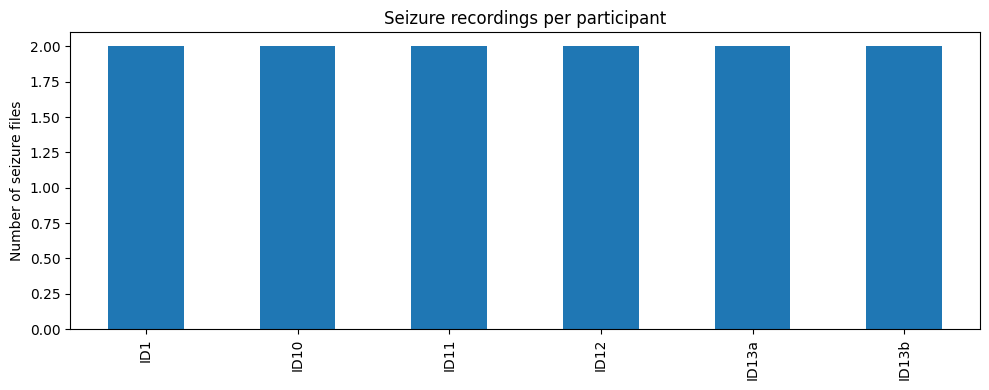

In [37]:

plt.figure(figsize=(10, 4))
participant_summary_df["n_recordings"].plot(kind="bar")
plt.xticks(range(len(participant_summary_df)), participant_summary_df["subject_id"], rotation=90)
plt.ylabel("Number of seizure files")
plt.title("Seizure recordings per participant")
plt.tight_layout()
plt.show()


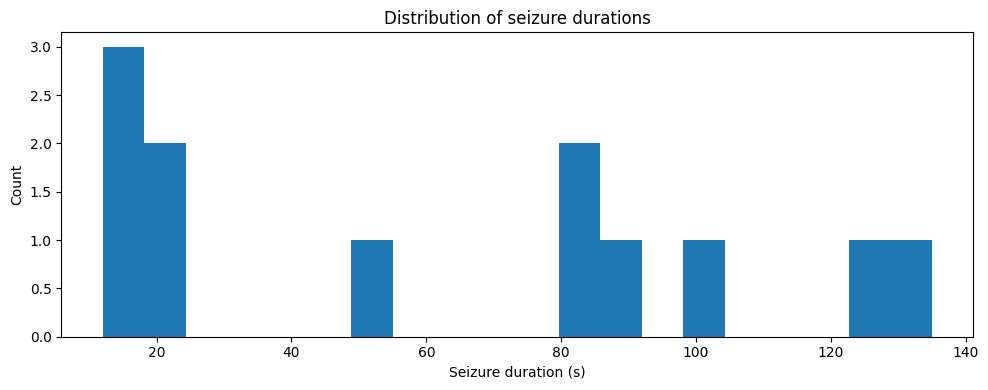

In [38]:

plt.figure(figsize=(10, 4))
plt.hist(manifest_df["seizure_duration_s"], bins=20)
plt.xlabel("Seizure duration (s)")
plt.ylabel("Count")
plt.title("Distribution of seizure durations")
plt.tight_layout()
plt.show()



## 6. Define the CobraBox feature set

This notebook keeps a small, interpretable feature set that is friendly for beginners.


In [39]:

ALL_FEATURE_OBJECTS = {
    "line_length": cb.feature.LineLength(),
    "amp_var": cb.feature.AmplitudeVariation(),
    "autocorr": cb.feature.Autocorr(dim="time", fs=FS),
    "sample_entropy": cb.feature.SampleEntropy(),
    "fractal_katz": cb.feature.FractalDimKatz(),
    "spike_count": cb.feature.SpikeCount(),
    "mean": cb.feature.Mean(dim="time"),
    "max": cb.feature.Max(dim="time"),
    "min": cb.feature.Min(dim="time"),
}

USE_FEATURES = list(ALL_FEATURE_OBJECTS.keys())
FEATURE_OBJECTS = {name: ALL_FEATURE_OBJECTS[name] for name in USE_FEATURES}

print("Number of feature families:", len(FEATURE_OBJECTS))
print("Features:", list(FEATURE_OBJECTS.keys()))


Number of feature families: 9
Features: ['line_length', 'amp_var', 'autocorr', 'sample_entropy', 'fractal_katz', 'spike_count', 'mean', 'max', 'min']



## 7. Process one recording with CobraBox sliding windows

This version uses **CobraBox's own `SlidingWindow` splitter** instead of creating
every window manually.

Why this is faster:
- the recording is wrapped into a CobraBox `Data` object only once
- window splitting is done by `cb.feature.SlidingWindow(...)`
- each feature is computed over the full window stream with a CobraBox pipeline
- we only assign string labels (`"seizure"`, `"non_seizure"`) **after** feature extraction

Important note:
- the splitter only handles the numeric EEG signal
- the labels are metadata we compute from seizure timing and then attach to each
  window row in the pandas table


In [40]:

def build_window_table(
    n_samples_total: int,
    crop_start_s: float,
    seizure_start_s: float,
    seizure_end_s: float,
    sample_is_seizure_crop: np.ndarray,
    fs: float,
    window_size: int,
    step_size: int,
    label_strategy: str,
    threshold: float,
) -> pd.DataFrame:
    window_starts = list(range(0, n_samples_total - window_size + 1, step_size))
    rows = []
    for window_idx, start_idx in enumerate(window_starts):
        end_idx = start_idx + window_size

        start_s_rel = start_idx / fs
        end_s_rel = end_idx / fs
        mid_s_rel = (start_s_rel + end_s_rel) / 2.0

        start_s_abs = crop_start_s + start_s_rel
        end_s_abs = crop_start_s + end_s_rel
        mid_s_abs = crop_start_s + mid_s_rel

        label, seizure_fraction = label_window(
            start_s=start_s_rel,
            end_s=end_s_rel,
            midpoint_s=mid_s_rel,
            sample_is_seizure=sample_is_seizure_crop,
            fs=fs,
            strategy=label_strategy,
            threshold=threshold,
        )

        rows.append({
            "window_idx": window_idx,
            "window_start_s": start_s_abs,
            "window_end_s": end_s_abs,
            "window_mid_s": mid_s_abs,
            "seizure_fraction_in_window": seizure_fraction,
            "target": label,
        })
    return pd.DataFrame(rows)


def feature_result_to_window_df(feature_name: str, feat_result) -> pd.DataFrame:
    """
    Convert a CobraBox feature result aggregated with ConcatAggregate into a
    window-level pandas table.
    """
    da = feat_result.data if hasattr(feat_result, "data") else feat_result
    if not isinstance(da, xr.DataArray):
        raise TypeError(f"Expected xarray.DataArray-like output, got {type(da)}")

    dims = list(da.dims)
    values = np.asarray(da.values)

    if "space" in dims:
        non_space_dims = [d for d in dims if d != "space"]
        if non_space_dims:
            stacked = da.stack(_window=non_space_dims).transpose("_window", "space")
            out = pd.DataFrame(
                stacked.values,
                columns=[f"{feature_name}__{str(ch)}" for ch in stacked.coords["space"].values],
            )
            out.insert(0, "window_idx", np.arange(len(out)))
            return out

        out = pd.DataFrame(
            [da.values],
            columns=[f"{feature_name}__{str(ch)}" for ch in da.coords["space"].values],
        )
        out.insert(0, "window_idx", [0])
        return out

    # Scalar per window or scalar overall
    if values.ndim == 0:
        out = pd.DataFrame({"window_idx": [0], feature_name: [float(values)]})
        return out

    if values.ndim == 1:
        out = pd.DataFrame({"window_idx": np.arange(len(values)), feature_name: values})
        return out

    # Last-resort fallback: flatten non-window axes into columns
    flat = values.reshape(values.shape[0], -1)
    out = pd.DataFrame(
        flat,
        columns=[f"{feature_name}__flat{i:03d}" for i in range(flat.shape[1])],
    )
    out.insert(0, "window_idx", np.arange(len(out)))
    return out


def extract_feature_table_cobrabox(signal, feature_name: str, feature_obj, window_size: int, step_size: int) -> pd.DataFrame:
    """
    Preferred path: run a CobraBox pipeline over the full recording:
        SlidingWindow -> Feature -> ConcatAggregate

    If ConcatAggregate is unavailable in the installed CobraBox version, fall back
    to iterating over the splitter output once per feature.
    """
    splitter = cb.feature.SlidingWindow(window_size=window_size, step_size=step_size)

    try:
        pipeline = cb.Chord(
            split=splitter,
            pipeline=feature_obj,
            aggregate=cb.feature.ConcatAggregate(),
        )
        feat_result = pipeline.apply(signal)
        return feature_result_to_window_df(feature_name, feat_result)

    except Exception as e:
        print(f"[fallback] {feature_name}: ConcatAggregate/Chord path failed with {type(e).__name__}: {e}")

        rows = []
        for window_idx, window_signal in enumerate(splitter(signal)):
            feat_result = feature_obj.apply(window_signal)
            feat_df = feature_result_to_window_df(feature_name, feat_result)
            feat_df["window_idx"] = window_idx
            rows.append(feat_df)

        if not rows:
            return pd.DataFrame({"window_idx": [], feature_name: []})
        return pd.concat(rows, ignore_index=True)


def process_one_recording(mat_path: Path, subject_id: str) -> pd.DataFrame:
    rec = load_swec_shortterm_mat(mat_path)

    if SKIP_RECORDINGS_WITH_FEWER_CHANNELS and not rec["enough_channels"]:
        return None

    eeg = rec["eeg"]
    channel_names = rec["channel_names"]

    sample_is_seizure_full = build_sample_timeline(
        n_samples=rec["n_samples"],
        seizure_start_idx=rec["seizure_start_idx"],
        seizure_end_idx=rec["seizure_end_idx"],
    )

    if RUN_MODE == "quick" and USE_QUICK_EXPERIMENT_CROP:
        crop_start_s, crop_end_s = choose_quick_experiment_crop(
            seizure_start_s=rec["seizure_start_s"],
            seizure_end_s=rec["seizure_end_s"],
            duration_seconds=rec["duration_s"],
            preictal_seconds=QUICK_PREICTAL_SECONDS,
            ictal_seconds=QUICK_ICTAL_SECONDS,
        )
    elif USE_REPRESENTATIVE_CROP:
        crop_start_s, crop_end_s = choose_representative_crop(
            duration_seconds=rec["duration_s"],
            seizure_start_s=rec["seizure_start_s"],
            crop_seconds=REPRESENTATIVE_CROP_SECONDS,
            seconds_before_onset=SECONDS_BEFORE_SEIZURE_ONSET,
        )
    else:
        crop_start_s, crop_end_s = 0.0, rec["duration_s"]

    crop_start_idx, crop_end_idx = interval_to_sample_bounds(
        crop_start_s, crop_end_s, FS, rec["n_samples"]
    )

    eeg_crop = eeg[crop_start_idx:crop_end_idx]
    sample_is_seizure_crop = sample_is_seizure_full[crop_start_idx:crop_end_idx]

    signal = numpy_to_signal(
        eeg_array=eeg_crop,
        channel_names=channel_names,
        fs=FS,
        source_file=str(mat_path),
        subject_id=subject_id,
    )

    n_samples_total = signal.data.sizes["time"]
    if n_samples_total < WINDOW_SIZE:
        raise ValueError(
            f"[{mat_path.name}] Crop is shorter than one window. "
            f"Crop samples={n_samples_total}, WINDOW_SIZE={WINDOW_SIZE}"
        )

    base_df = build_window_table(
        n_samples_total=n_samples_total,
        crop_start_s=crop_start_s,
        seizure_start_s=rec["seizure_start_s"],
        seizure_end_s=rec["seizure_end_s"],
        sample_is_seizure_crop=sample_is_seizure_crop,
        fs=FS,
        window_size=WINDOW_SIZE,
        step_size=STEP_SIZE,
        label_strategy=LABEL_STRATEGY,
        threshold=SEIZURE_THRESHOLD,
    )

    meta_df = pd.DataFrame({
        "window_idx": base_df["window_idx"],
        "subject_id": subject_id,
        "recording_id": f"{subject_id}__{mat_path.stem}",
        "fileName": mat_path.name,
        "crop_start_s": crop_start_s,
        "crop_end_s": crop_end_s,
        "crop_duration_s": crop_end_s - crop_start_s,
        "seizure_start_s": rec["seizure_start_s"],
        "seizure_end_s": rec["seizure_end_s"],
        "original_n_channels": rec["original_n_channels"],
        "n_channels": rec["used_n_channels"],
        "label_strategy": LABEL_STRATEGY,
    })

    feature_tables = []
    for feature_name, feature_obj in FEATURE_OBJECTS.items():
        feat_df = extract_feature_table_cobrabox(
            signal=signal,
            feature_name=feature_name,
            feature_obj=feature_obj,
            window_size=WINDOW_SIZE,
            step_size=STEP_SIZE,
        )
        feature_tables.append(feat_df)

    merged_df = reduce(
        lambda left, right: pd.merge(left, right, on="window_idx", how="left"),
        [meta_df, base_df] + feature_tables,
    )

    return merged_df



## 8. Run the preprocessing pipeline

This step now uses the CobraBox-native splitter path first:

- `SlidingWindow(window_size=..., step_size=...)`
- feature pipeline
- `ConcatAggregate()` to bring the window results back into one table per feature

That usually removes the biggest slowdown from the previous version, where
features were computed one window at a time in Python.


In [ ]:

subject_tables = []
processed_manifest_rows = []
processing_errors = []

for subject_dir in subject_dirs:
    subject_id = subject_dir.name
    seizure_files = discover_seizure_files(subject_dir, MAX_SEIZURE_FILES_PER_SUBJECT_EFFECTIVE)

    print(f"\n=== {subject_id} ===")
    for mat_path in seizure_files:
        print(f"\n*** {mat_path.name} ***")
        try:
            rec = load_swec_shortterm_mat(mat_path)
            usable = (not SKIP_RECORDINGS_WITH_FEWER_CHANNELS) or rec["enough_channels"]

            processed_manifest_rows.append({
                "subject_id": subject_id,
                "fileName": mat_path.name,
                "duration_s": rec["duration_s"],
                "seizure_duration_s": rec["seizure_duration_s"],
                "original_n_channels": rec["original_n_channels"],
                "used_n_channels": rec["used_n_channels"] if usable else 0,
                "used_for_model": usable,
            })

            if not usable:
                print(f"Skipping {mat_path.name}: only {rec['original_n_channels']} channels")
                continue

            t0 = time.time()
            df_rec = process_one_recording(mat_path, subject_id)
            elapsed = time.time() - t0
            print(f"Processed {mat_path.name} -> {len(df_rec):,} windows in {elapsed:.1f} s")

            if df_rec is not None and not df_rec.empty:
                subject_tables.append(df_rec)

        except Exception as e:
            processing_errors.append({
                "subject_id": subject_id,
                "fileName": mat_path.name,
                "error": str(e),
            })
            print(f"ERROR in {subject_id} / {mat_path.name}: {e}")

if not subject_tables:
    raise ValueError("No usable feature tables were created.")

all_features_df = pd.concat(subject_tables, ignore_index=True)
processed_manifest_df = pd.DataFrame(processed_manifest_rows)
processing_errors_df = pd.DataFrame(processing_errors)

print("\nCombined feature table shape:", all_features_df.shape)
print("Participants in feature table:", all_features_df["subject_id"].nunique())
print("Recordings in feature table:", all_features_df["recording_id"].nunique())



=== ID1 ===

*** Sz1.mat ***



## 9. Inspect the feature table


In [ ]:

all_features_df.head()


In [ ]:

all_features_df["target"].value_counts(dropna=False)


In [ ]:

windows_per_subject_df = (
    all_features_df.groupby("subject_id", as_index=False)
    .agg(
        n_windows=("window_idx", "count"),
        n_recordings=("recording_id", "nunique"),
        seizure_windows=("target", lambda s: int((s == "seizure").sum())),
        non_seizure_windows=("target", lambda s: int((s == "non_seizure").sum())),
    )
    .sort_values("subject_id")
)

windows_per_subject_df



## 10. Save outputs

This notebook saves both metadata and extracted features.


In [ ]:

manifest_path = out_dir / "recording_manifest.csv"
participant_summary_path = out_dir / "participant_summary.csv"
overall_summary_path = out_dir / "overall_summary.csv"
combined_parquet_path = out_dir / "all_window_features.parquet"
combined_csv_path = out_dir / "all_window_features.csv"
processing_errors_path = out_dir / "processing_errors.csv"

manifest_df.to_csv(manifest_path, index=False)
participant_summary_df.to_csv(participant_summary_path, index=False)
overall_summary_df.to_csv(overall_summary_path, index=False)
all_features_df.to_parquet(combined_parquet_path, index=False)
all_features_df.to_csv(combined_csv_path, index=False)
processing_errors_df.to_csv(processing_errors_path, index=False)

for subject_id, df_sub in all_features_df.groupby("subject_id"):
    df_sub.to_parquet(out_dir / f"{subject_id}_window_features.parquet", index=False)
    df_sub.to_csv(out_dir / f"{subject_id}_window_features.csv", index=False)

print("Saved to:", out_dir.resolve())
print("-", manifest_path.name)
print("-", participant_summary_path.name)
print("-", overall_summary_path.name)
print("-", combined_parquet_path.name)
print("-", combined_csv_path.name)
print("-", processing_errors_path.name)
print("- one CSV + one parquet per participant")



## 11. Beginner-friendly examples of what to look at next

At this point you now have:

- a table describing the dataset
- one row per window
- one label per window
- one subject ID per row
- feature columns ready for machine learning

The next notebook can focus on beginner-friendly machine learning steps such as:

1. loading the saved feature table
2. separating metadata columns from feature columns
3. converting labels into 0 and 1
4. train/test splits or leave-one-subject-out evaluation
5. fitting a simple classifier
6. reading confusion matrices and metrics
